# Clasificación de sentimiento: Preparación de datos
En esta celda, vamos a visualizar los datos de nuestro dataset artificial para crear un modelo de NLP que clasifique el prompt introducido por el usuario en 4 categorías:
- Inaceptable
- Alto riesgo
- Riesgo limitado
- Riesgo mínimo

Esto es un ejercicio similar al análisis de sentimiento que hemos realizado durante el módulo, pero en este caso, se conoce como text classification supervisada multiclase, no sentiment analysis. 


In [27]:
%pip install scikit-learn   
%pip install pandas spacy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 5.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 5.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 5.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.1 MB 5.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 5.5 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 5.4 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 5.4 MB/s

In [18]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.9 MB 5.6 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.9 MB 5.3 MB/s eta 0:00:03
     -------- ------------------------------- 2.9/12.9 MB 5.1 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.9 MB 5.1 MB/s eta 0:00:02
     --------------- ------------------------ 5.0/12.9 MB 5.1 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.9 MB 5.0 MB/s eta 0:00:02
     --------------------- ------------------ 7.1/12.9 MB 5.0 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.9 MB 5.0 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.9 MB 5.0 MB/s eta 0:00:01
     ------------------------------- -------- 10.2/12.9 MB 5.0 MB/s eta 0:00:01
     ---------------------------------- ----- 11.3/12.9 MB 5.1 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.9 M

## Carga del dataset 
Cargamos el dataset y lo guardamos en archivos separados 

In [6]:
# Abrimos el dataset
from sklearn.model_selection import train_test_split
import pandas as pd
path = "data/dataset_riesgo.csv"
import pandas as pd
df = pd.read_csv(path)
# Separamos las características (X) y la variable objetivo (y)
X = df["descripcion"]
y = df["etiqueta"]


# Imprimimos las formas de los conjuntos de entrenamiento y prueba
print("Conjunto:", X.shape, y.shape)


Conjunto: (300,) (300,)


# Primer acercamiento a los datos: 

1. Verificaciones básicas
Objetivo: confirmar que no hay nulos ni clases desbalanceadas.
2. Comprobar duplicados
3. Longitud de los textos
4. Limpieza mínima del texto
5. Split con estratificación
6. Guardar los splits (opcional pero profesional)


In [ ]:
#Comprobamos si nuestro dataset tenía duplicados antes de la división
df.duplicated().sum()

np.int64(0)

In [ ]:
# Mostramos las primeras filas del conjunto de entrenamiento
X.head()
# Mostramos las últimas filas del conjunto de entrenamiento
X.tail()


0    Sistema de puntuación social que clasifica a c...
1    Sistema de identificación biométrica facial en...
2    Plataforma que usa técnicas subliminales en an...
3    Sistema que analiza microexpresiones faciales ...
4    Herramienta que explota el deterioro cognitivo...
Name: descripcion, dtype: str

In [10]:
# Mostramos las últimas filas del conjunto de entrenamiento
y.head()
# mostramos las últimas filas del conjunto de entrenamiento
y.tail()

295    riesgo_minimo
296    riesgo_minimo
297    riesgo_minimo
298    riesgo_minimo
299    riesgo_minimo
Name: etiqueta, dtype: str

In [11]:
#Mostramos la distribución de las etiquetas en el conjunto de entrenamiento como porcentajes
print("Distribución de etiquetas en el conjunto de entrenamiento:")
print(y.value_counts(normalize=True) * 100)

Distribución de etiquetas en el conjunto de entrenamiento:
etiqueta
alto_riesgo        30.000000
inaceptable        25.666667
riesgo_limitado    22.333333
riesgo_minimo      22.000000
Name: proportion, dtype: float64


In [ ]:
# Analizamos la longitud de las descripciones para ver si hay alguna diferencia entre las clases
df["longitud"] = df["descripcion"].apply(len)
df["longitud"].describe()

count    300.000000
mean     186.453333
std       17.869683
min      143.000000
25%      175.000000
50%      186.000000
75%      198.250000
max      238.000000
Name: longitud, dtype: float64

In [ ]:
#Creamos una nueva columna con el texto limpio
from functions import limpiar_texto

df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)

In [ ]:
# Vectorización + modelo baseline
X = df["descripcion_limpia"]
y = df["etiqueta"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# guardamos los conjuntos de entrenamiento y prueba en archivos CSV en path "data/processed/"
train_df = pd.DataFrame({"descripcion": X_train, "etiqueta": y_train})
test_df = pd.DataFrame({"descripcion": X_test, "etiqueta": y_test

In [ ]:
# Convertimos el dataset en vectores numéricos utilizando TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    alto_riesgo       0.82      1.00      0.90        18
    inaceptable       0.94      0.94      0.94        16
riesgo_limitado       1.00      0.92      0.96        13
  riesgo_minimo       1.00      0.77      0.87        13

       accuracy                           0.92        60
      macro avg       0.94      0.91      0.92        60
   weighted avg       0.93      0.92      0.92        60



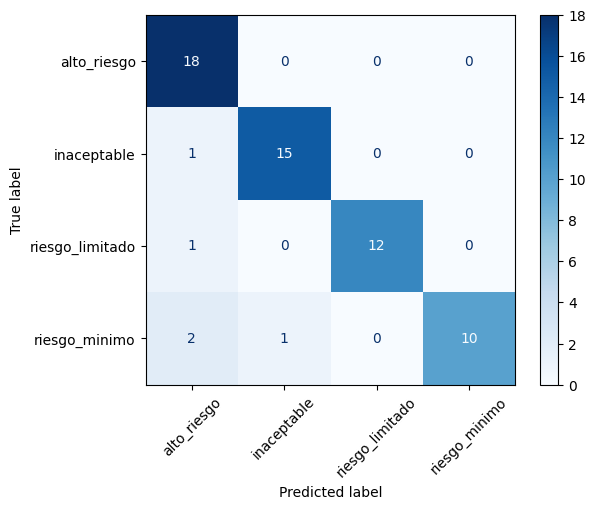

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

disp.plot(cmap="Blues")
plt.xticks(rotation=45)
plt.show()

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression())
])

In [32]:
import numpy as np
from sklearn.svm import LinearSVC
vectorizer = model.named_steps["tfidf"]
clf = model.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())

for i, clase in enumerate(clf.classes_):
    top10 = np.argsort(clf.coef_[i])[-10:]
    print(f"\nClase: {clase}")
    print(feature_names[top10])

AttributeError: 'LogisticRegression' object has no attribute 'named_steps'